In [1]:
# Import libraries
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('Mall_Customers.csv')

# Show the first 5 rows to check
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
# Select features for clustering
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = data[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check the first 5 rows after scaling
pd.DataFrame(X_scaled, columns=features).head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


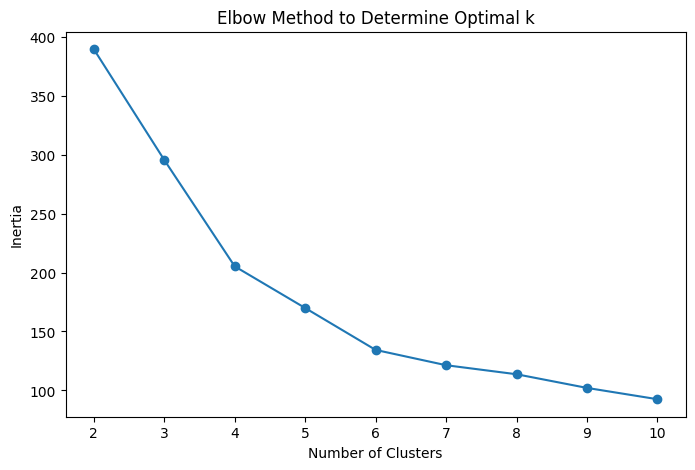

In [3]:
# Find optimal number of clusters using Elbow Method
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the results
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method to Determine Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [4]:

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the dataset
data['Cluster'] = clusters

# Show first 5 rows with cluster assignment
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,3
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [5]:
# Evaluate clustering
silhouette = silhouette_score(X_scaled, clusters)
calinski = calinski_harabasz_score(X_scaled, clusters)
davies = davies_bouldin_score(X_scaled, clusters)

print("Silhouette Score:", silhouette)
print("Calinski-Harabasz Score:", calinski)
print("Davies-Bouldin Score:", davies)

Silhouette Score: 0.40846873777345605
Calinski-Harabasz Score: 123.41870976849417
Davies-Bouldin Score: 0.8889693268899006


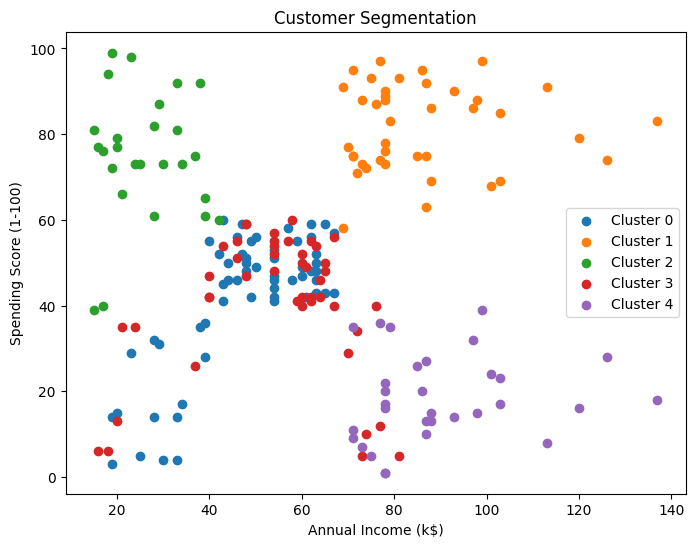

In [6]:
# Visualize clusters
plt.figure(figsize=(8,6))
for i in range(k):
    plt.scatter(
        data[data['Cluster'] == i]['Annual Income (k$)'],
        data[data['Cluster'] == i]['Spending Score (1-100)'],
        label=f'Cluster {i}'
    )
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation')
plt.legend()
plt.show()